In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="6"

# Flow

We input images and masks. The mask and image size must match, but between images they can have different sizes.

> We want to know which patches correspond to the mask area. So do we resize both the image and the mask and overlap the patches?
> Answer: Yes. This is what we do in the original. So might as well during preprocessing already compute the resized mask and return tensors that have the mask as well as original shape bounding box information. These will be sized for the entire resized image and so will be larger than required.

Compute the valid size for the image, resize and pad the image and mask in parallel. Batch-wise compute mask overlaps using the area interpolate method for all segmentations at once.

Batch-wise compute the patch bounding boxes in the original image sizes. We can first compute the patch bounding boxes for the resized images and then scale based on the scale parameters from the resize.

Finally, for each we need to create the valid mask.

All of these should be 1D arrays that correspond to the shape of the output from DINOv3.

In [3]:
import torch
import gc

# Preprocessing

## Preprocess Images

In [4]:
from aidan_lib.models.dino_lib_compiled import preprocess_imgs, preprocess_imgs_w_masks, get_dino_from_repo, get_compiled_dino_from_repo

Unable to import quantization op. Please install modelopt library (https://github.com/NVIDIA/TensorRT-Model-Optimizer?tab=readme-ov-file#installation) to add support for compiling quantized models


In [5]:
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"PyTorch CUDA Version: {torch.version.cuda}")
print(f"Device Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

CUDA Available: True
PyTorch CUDA Version: 12.4
Device Name: NVIDIA H100 80GB HBM3


In [6]:
device = "cuda"
batch_size = 16
input_size = 1024
dummy_input = torch.randn(batch_size, 3, input_size, input_size, dtype=torch.bfloat16, device=device)

import time
from tqdm import tqdm
def evaluate_model(model, batch_size, iterations=100, warmup_iters=10):
    time_in_model = 0
    with torch.autocast(device_type=device, dtype=torch.bfloat16):
        for i in tqdm(range(iterations + warmup_iters)):
            dummy_input = torch.randn(batch_size, 3, input_size, input_size, dtype=torch.bfloat16, device=device)
            start = time.perf_counter()
            model(dummy_input)
            if i > warmup_iters:
                time_in_model += time.perf_counter() - start

    print(f"Time per iteration: {time_in_model / iterations:0.3f}s")
    return time_in_model / iterations


In [7]:
# repo_dino = get_dino_from_repo(device="cuda")

In [8]:
# evaluate_model(repo_dino.forward_features, iterations=1000)

In [9]:
RUN_TESTS = False

In [10]:
if RUN_TESTS:
    compiled_repo_dino = get_compiled_dino_from_repo(
        checkpoint="facebook/dinov3-vits16-pretrain-lvd1689m",
        device=device,
        backend="inductor",
        warmup_batch_size=batch_size,
        max_side_len=input_size,
        warmup=False,
        dynamic=False
    )

In [11]:
if RUN_TESTS:
    test_batch_sizes = [1, 2, 4, 8, 16]

In [12]:
if RUN_TESTS:
    images_per_second = []
    for batch_size in test_batch_sizes:
        print(f"Testing with {batch_size}")
        seconds_per_iteration = evaluate_model(compiled_repo_dino, batch_size=batch_size, iterations=100, warmup_iters=20)
        images_per_second.append(batch_size / seconds_per_iteration)
        print(f"Got {images_per_second[-1]} images per second")

In [13]:
if RUN_TESTS:
    del compiled_repo_dino
    gc.collect()
    torch.cuda.empty_cache()

In [14]:
from torchvision.io import read_image, ImageReadMode

In [15]:
from aidan_lib.definitions import DATA_DIR
test_img_dir = DATA_DIR / "imgs"
assert test_img_dir.exists()

test_img_path = test_img_dir / "thompson.png"
assert test_img_path.exists()

In [16]:
# test_img = read_image(str(test_img_path), ImageReadMode.RGB)
# test_img = test_img.float() / 255
# test_img = test_img.to(device)
# test_imgs, grid_sizes, original_sizes, scales, valids = preprocess_imgs([test_img], max_side_len=1024, patch_size=16, normalize=True)

In [17]:
# print(test_imgs.shape)
# with torch.autocast(device, dtype=torch.bfloat16):
#     dino_out = compiled_repo_dino(test_imgs)

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from aidan_lib.models.dino_lib_compiled import DINOv3CompiledHarness

# If you don't already have one instantiated, run this cell
# to instantiate the compiled harness.
harness = DINOv3CompiledHarness(
    checkpoint="facebook/dinov3-vits16-pretrain-lvd1689m", 
    device=device,
    max_side_len=1024,
    warmup=True,
    warmup_batch_size=1
)


Loading dino model
Compiling dino model (backend: inductor, dynamic: False)
Performing warmup pass with batch size 1...


In [19]:
# Load all test images from the data directory
test_img_dir = DATA_DIR / "imgs"
img_paths = list(test_img_dir.glob("*.png")) + list(test_img_dir.glob("*.jpg")) + list(test_img_dir.glob("*.jpeg"))

imgs = []
orig_imgs_np = []

for p in img_paths:
    img = read_image(str(p), ImageReadMode.RGB)
    imgs.append((img.float() / 255.0).to(device))
    # Store numpy versions for matplotlib later
    orig_imgs_np.append(img.permute(1, 2, 0).numpy())
    
print(f"Loaded {len(imgs)} test images.")


Loaded 3 test images.


In [20]:
# Extract the patch features
# DINOv3CompiledHarness.extract_patch_features returns features, cls_tokens, grid_sizes, and original_sizes
features_list, cls_tokens, grid_sizes_list, original_sizes_list = harness.extract_patch_features(imgs)


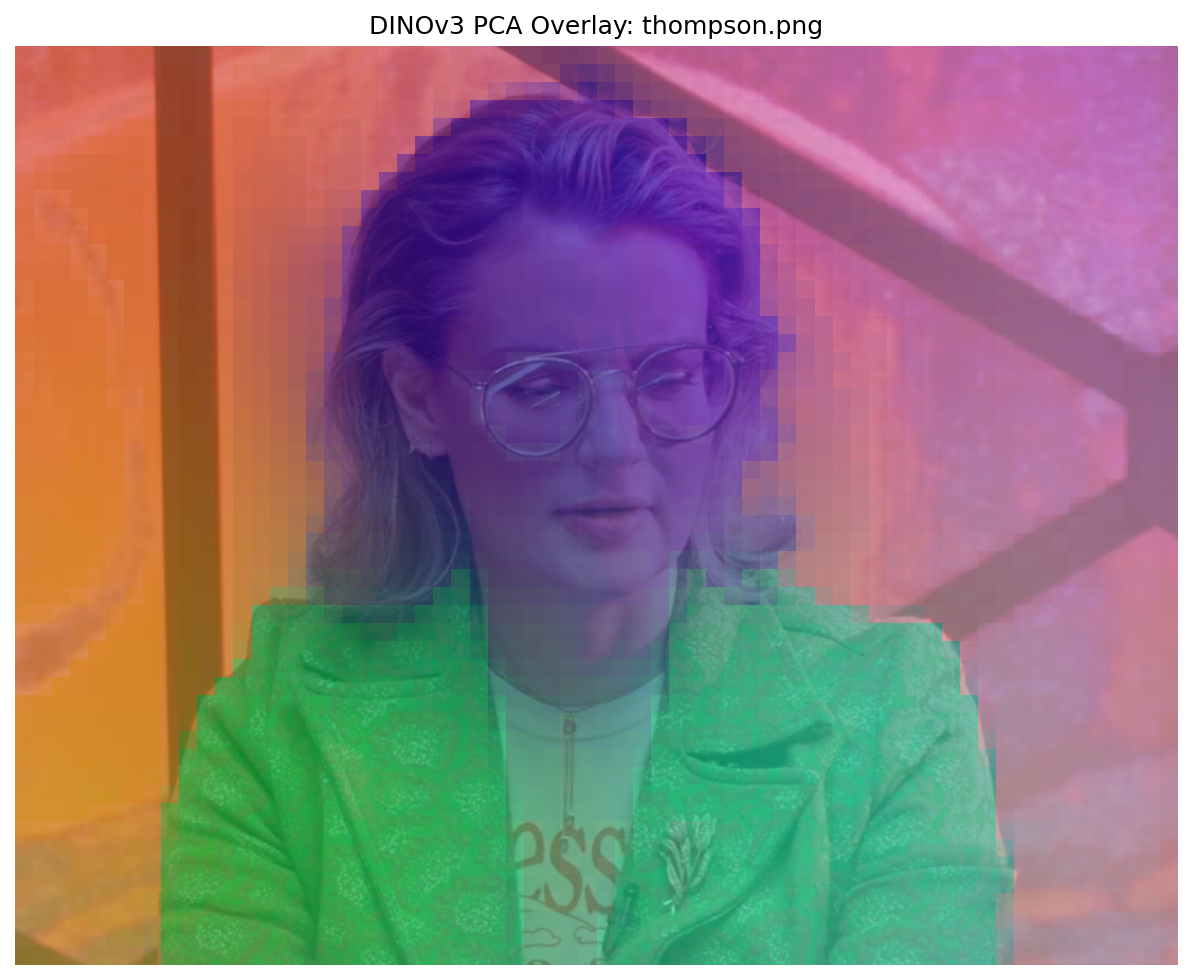

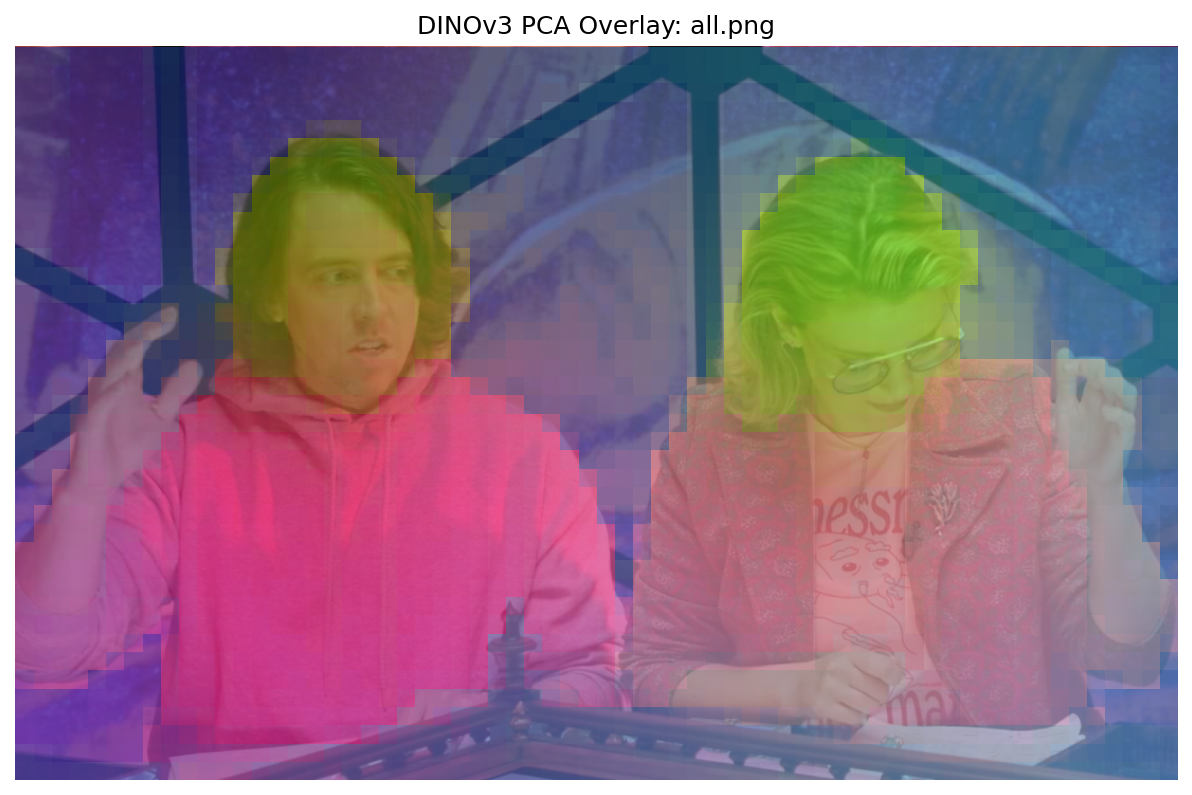

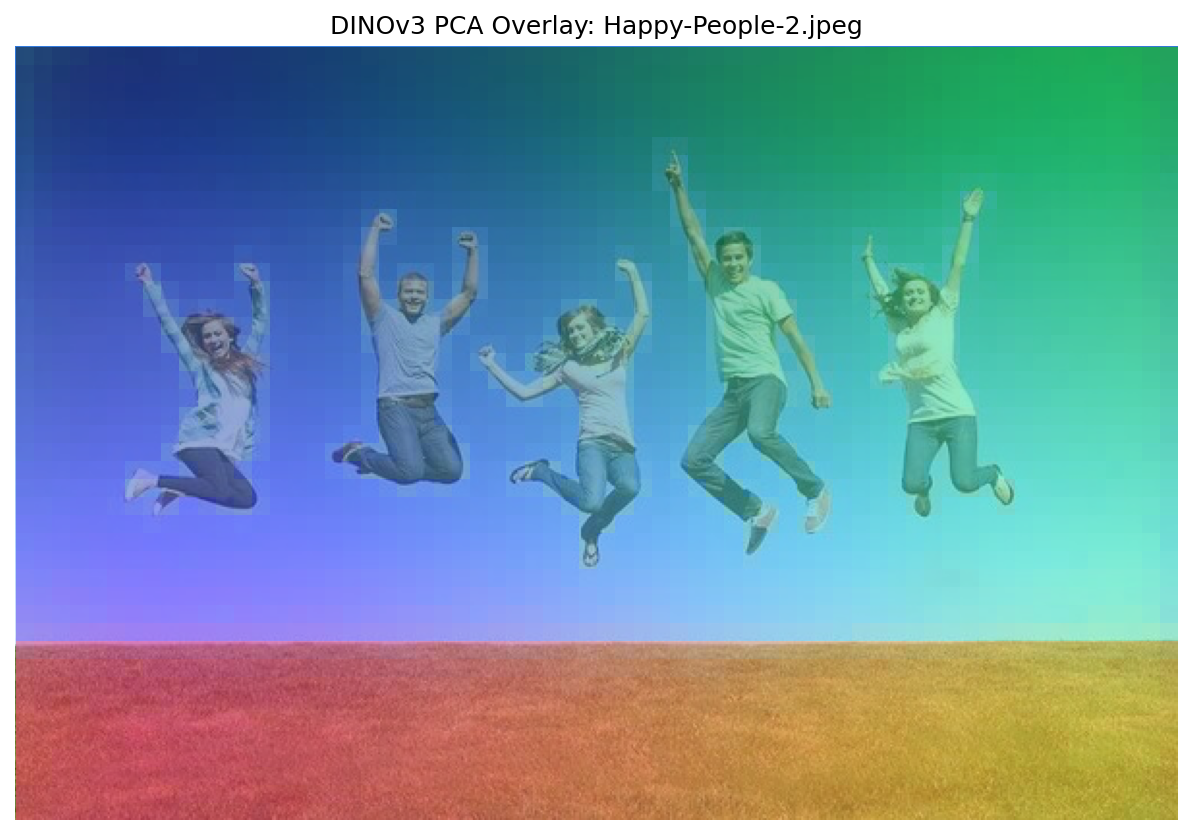

In [21]:
# Run PCA and visualize the bounding boxes per image
for i in range(len(imgs)):
    feat = features_list[i] # Shape: [H_patches, W_patches, dim]
    grid_h, grid_w = grid_sizes_list[i]
    orig_w, orig_h = original_sizes_list[i]
    
    # Reshape features down to (Num_patches, Dim) for PCA
    feat_flat = feat.view(-1, feat.shape[-1]).cpu().numpy()
    
    # Project down to 3 components to visualize as RGB colors
    pca = PCA(n_components=3)
    pca_feat = pca.fit_transform(feat_flat)
    
    # Normalize PCA components to [0, 1] for RGB projection
    pca_min = pca_feat.min(axis=0)
    pca_max = pca_feat.max(axis=0)
    pca_feat_norm = (pca_feat - pca_min) / (pca_max - pca_min)
    pca_feat_norm = pca_feat_norm.reshape(grid_h, grid_w, 3)
    
    # Plot the original image
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=150)
    ax.imshow(orig_imgs_np[i])
    
    # Calculate exactly how the image was scaled during preprocessing
    max_side_len = harness.max_side_len
    patch_size = harness.patch_size
    scale = max_side_len / max(orig_w, orig_h)
    
    new_w, new_h = orig_w * scale, orig_h * scale
    resize_w = round(new_w / patch_size) * patch_size
    resize_h = round(new_h / patch_size) * patch_size
    
    scale_w = resize_w / orig_w
    scale_h = resize_h / orig_h
    
    # Draw patches with PCA colors
    for h_idx in range(grid_h):
        for w_idx in range(grid_w):
            color = pca_feat_norm[h_idx, w_idx]
            
            # Map box coordinates back to original image space
            x = w_idx * patch_size / scale_w
            y = h_idx * patch_size / scale_h
            w = patch_size / scale_w
            h = patch_size / scale_h
            
            rect = patches.Rectangle(
                (x, y), w, h,
                linewidth=0,
                edgecolor='none',
                facecolor=color,
                alpha=0.6 # Transparency overlap
            )
            ax.add_patch(rect)
    
    ax.axis('off')
    plt.title(f"DINOv3 PCA Overlay: {img_paths[i].name}")
    plt.show()
